# OVERVIEW:

The following runs hypothesis tests on three different SNODAS assimilation dates (12/11/22, 12/28/23, and 01/10/24) with and without UMRB stations. The purpose of the hypothesis test is to see if the assimilations with UMRB stations is indeed significantly different from the assimilation without UMRB stations.

In [21]:
# Load a
import sys
import os as os

import geopandas as gpd
import numpy as np
from numpy.polynomial import Polynomial
import psycopg2
from netCDF4 import Dataset

from tqdm import tqdm
from multiprocessing import Pool
import statsmodels.api as sm
from scipy import stats
# from scipy import optimize

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature as cfNEF

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
#import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

import rasterio
import xarray as xr

import random
import subprocess
import netCDF4 as nc
import shutil

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
import seaborn as sns
from scipy.stats import gaussian_kde

import pathlib
import glob
import pandas as pd

from sklearn.metrics import r2_score
from scipy.stats import normaltest

import geopandas as gpd
import xarray as xr
from rasterio import features
from shapely.geometry import mapping
import rioxarray
import scipy


import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
from scipy import stats



# Hypothesis test (T-test) for the 12/11/22 assimilation:

Load netCDF data from with and without UMRB stations and clip to UMRB region (UMRB region shapefile is from USGS watershed boundary set and is the full Missouri Basin extent):

- Load data from assimilation With UMRB stations

In [22]:
## Load data from assmilation with UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_2022121112.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray:
With_UMRB_12_22_data = xr.open_dataset(file_path)

With_UMRB_12_22_data = With_UMRB_12_22_data.compute()

With_UMRB_12_22_data


<xarray.Dataset> Size: 62MB
Dimensions:     (lat: 1324, lon: 5851, nv: 2)
Coordinates:
  * lat         (lat) float64 11kB 51.78 51.77 51.76 51.75 ... 40.77 40.76 40.75
  * lon         (lon) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 21kB 51.78 51.77 51.77 ... 40.76 40.76 40.75
    lon_bounds  (lon, nv) float64 94kB -112.3 -112.3 -112.3 ... -63.52 -63.52
    Data        (lat, lon) float64 62MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-06-12 19:26:02 UTC created by module: snodas_idw.py
    comment:         2024-06-12 19:26:02 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

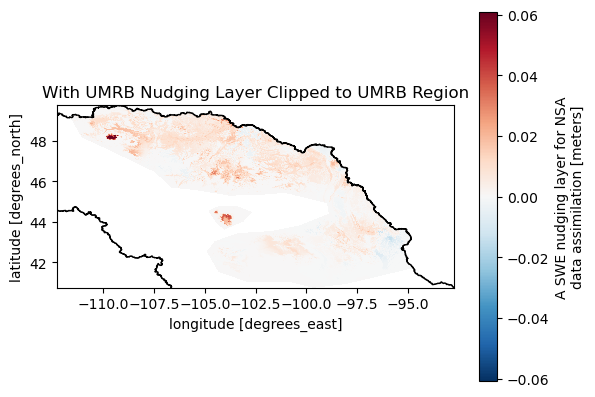

In [23]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
With_UMRB_12_22_data = With_UMRB_12_22_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
With_UMRB_12_22_data = With_UMRB_12_22_data.rio.write_crs('WGS84') #unprojected lon/lat

With_UMRB_12_22_data = With_UMRB_12_22_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
With_UMRB_12_22_data = With_UMRB_12_22_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(With_UMRB_12_22_data.rio.crs)

#clip the model grid to the watershed
With_UMRB_12_22_data_clipped = With_UMRB_12_22_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
With_UMRB_12_22_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('With UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

- Load data from assmilation without UMRB stations

In [24]:
## Load data from assmilation without UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_NO_UMRB\ssm1054_snodas_idw_test_2022121112_east0.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray. The resulting data structure is called a DataFrame
NO_UMRB_12_22_data = xr.open_dataset(file_path)

NO_UMRB_12_22_data = NO_UMRB_12_22_data.compute()

NO_UMRB_12_22_data


<xarray.Dataset> Size: 62MB
Dimensions:     (lat: 1324, lon: 5851, nv: 2)
Coordinates:
  * lat         (lat) float64 11kB 51.78 51.77 51.76 51.75 ... 40.77 40.76 40.75
  * lon         (lon) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 21kB 51.78 51.77 51.77 ... 40.76 40.76 40.75
    lon_bounds  (lon, nv) float64 94kB -112.3 -112.3 -112.3 ... -63.52 -63.52
    Data        (lat, lon) float64 62MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-06-12 20:31:43 UTC created by module: snodas_idw.py
    comment:         2024-06-12 20:31:43 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

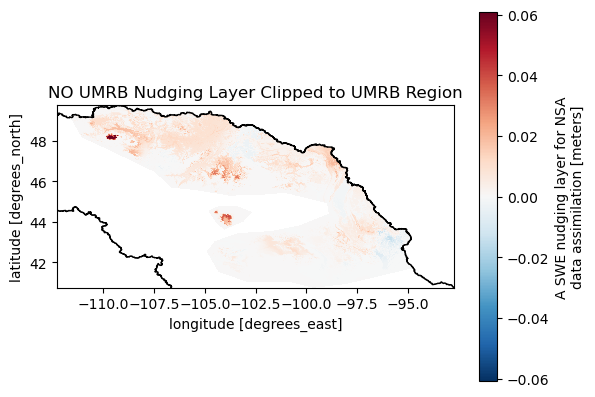

In [25]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
NO_UMRB_12_22_data = NO_UMRB_12_22_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
NO_UMRB_12_22_data = NO_UMRB_12_22_data.rio.write_crs('WGS84') #unprojected lon/lat

NO_UMRB_12_22_data = NO_UMRB_12_22_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
NO_UMRB_12_22_data = NO_UMRB_12_22_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(NO_UMRB_12_22_data.rio.crs)

#clip the model grid to the watershed
NO_UMRB_12_22_data_clipped = NO_UMRB_12_22_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
NO_UMRB_12_22_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('NO UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

### Extract the data from the netCDF files for each assimilation and analyze

With UMRB Stations data anlaysis:

- Extract data from With UMRB run

In [26]:
## Extract data from With UMRB run ##

With_UMRB_12_22_data_final = With_UMRB_12_22_data_clipped['Data']

With_UMRB_12_22_data_final = pd.DataFrame(With_UMRB_12_22_data_clipped['Data'])

# Stack all columns into a single column
With_UMRB_12_22_data_final = With_UMRB_12_22_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
With_UMRB_12_22_data_final = pd.DataFrame(With_UMRB_12_22_data_final, columns=['values'])

# Create array without any zero and -99999 values
#With_UMRB_12_22_data_final = (With_UMRB_12_22_data_final[(With_UMRB_12_22_data_final != 0) & (With_UMRB_12_22_data_final != -99999)])

With_UMRB_12_22_data_final = With_UMRB_12_22_data_final.dropna()

With_UMRB_12_22_data_final = With_UMRB_12_22_data_final * 1000

- Compute basic statistics With UMRB Run

In [27]:
# Compute basic statistics
data_min = np.min(With_UMRB_12_22_data_final)
data_max = np.max(With_UMRB_12_22_data_final)
data_mean = np.mean(With_UMRB_12_22_data_final)
data_std = np.std(With_UMRB_12_22_data_final)

# Compute percentiles
percentiles = np.percentile(With_UMRB_12_22_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -14.791510067880154
Maximum value: 60.95999851822853
Mean value: 2.9678859790452106
Standard deviation: values    5.060733
dtype: float64
25th percentile: 3.4555252881318665e-05
Median (50th percentile): 0.8353496668860316
75th percentile: 5.189943010918796


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in With UMRB run

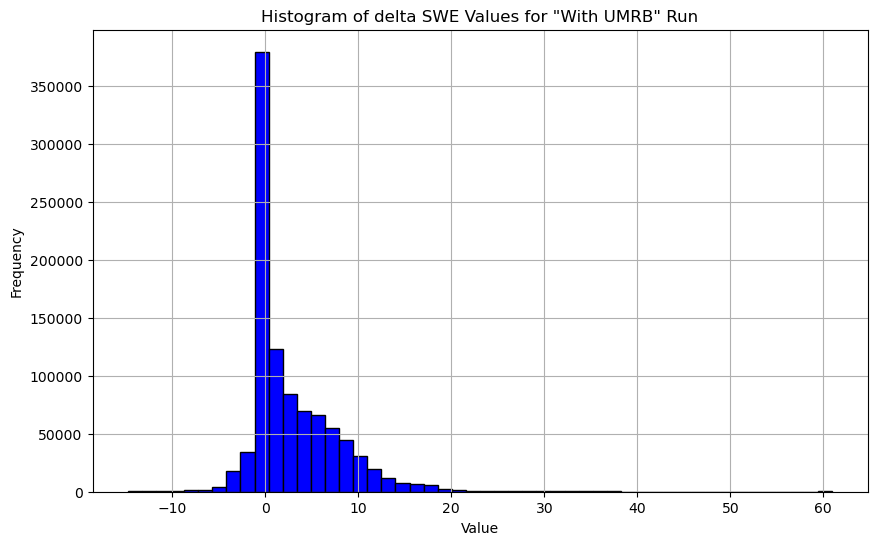

In [28]:
## Create histogram showing the delta SWE in With UMRB run ##

data_flat = With_UMRB_12_22_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "With UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- Extract data from NO UMRB run

In [29]:
## Extract data from NO UMRB run ##

NO_UMRB_12_22_data_final = NO_UMRB_12_22_data_clipped['Data']

NO_UMRB_12_22_data_final = pd.DataFrame(NO_UMRB_12_22_data_clipped['Data'])

# Stack all columns into a single column
NO_UMRB_12_22_data_final = NO_UMRB_12_22_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
NO_UMRB_12_22_data_final = pd.DataFrame(NO_UMRB_12_22_data_final, columns=['values'])

# Create array without any zero and -99999 values
#NO_UMRB_12_22_data_final = (NO_UMRB_12_22_data_final[(NO_UMRB_12_22_data_final != 0) & (NO_UMRB_12_22_data_final != -99999)])

NO_UMRB_12_22_data_final = NO_UMRB_12_22_data_final.dropna()

NO_UMRB_12_22_data_final = NO_UMRB_12_22_data_final * 1000

- Compute basic statistics for NO UMRB Run

In [30]:
# Compute basic statistics
data_min = np.min(NO_UMRB_12_22_data_final)
data_max = np.max(NO_UMRB_12_22_data_final)
data_mean = np.mean(NO_UMRB_12_22_data_final)
data_std = np.std(NO_UMRB_12_22_data_final)

# Compute percentiles
percentiles = np.percentile(NO_UMRB_12_22_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -14.791510999202728
Maximum value: 60.95999851822853
Mean value: 2.864294255456118
Standard deviation: values    5.066226
dtype: float64
25th percentile: 0.00011096928531628691
Median (50th percentile): 0.7005749503150582
75th percentile: 4.700447781942785


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in NO UMRB run

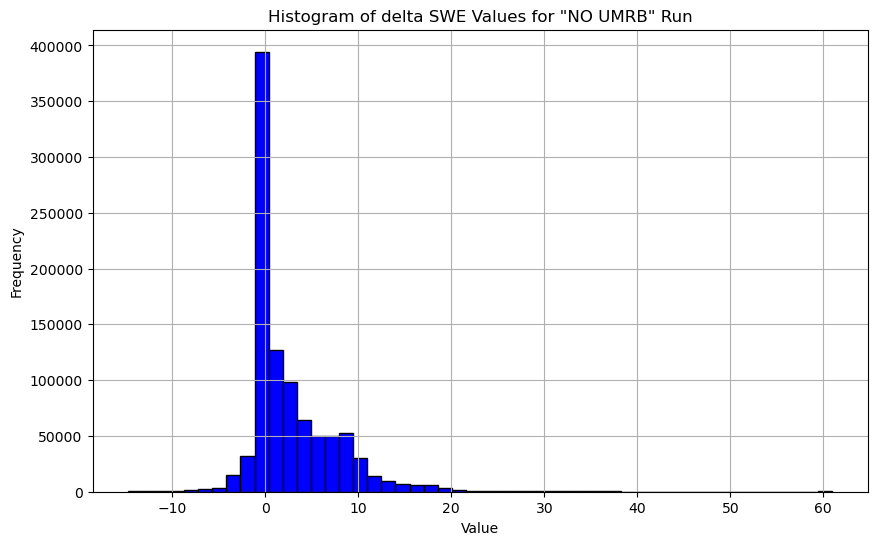

In [31]:
## Create histogram showing the delta SWE in NO UMRB run ##

data_flat_NO = NO_UMRB_12_22_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat_NO, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "NO UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Check for normality of With UMRB dataset (lillietest):

 - $H_0$: The delta SWE distribution of the IDW assimilations are (standard) normal.
 - $H_1$: The delta SWE distribution of the IDW assimilations are not (standard) normal.

In [32]:
# Perform normality test
statistic, p_value = normaltest(With_UMRB_12_22_data_final)

# Print results
p_value

array([0.])

In [33]:
# Perform normality test
statistic, p_value = normaltest(NO_UMRB_12_22_data_final)
# Print results
p_value

array([0.])

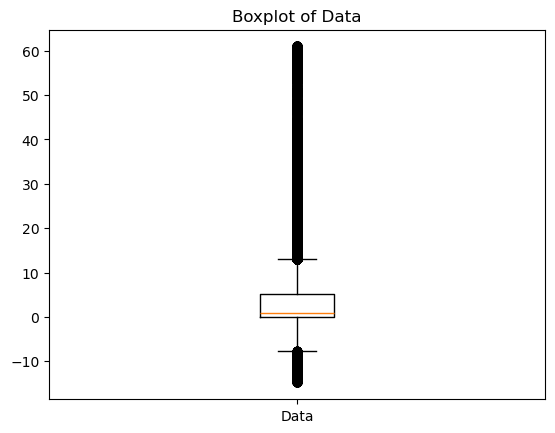

In [34]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(With_UMRB_12_22_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

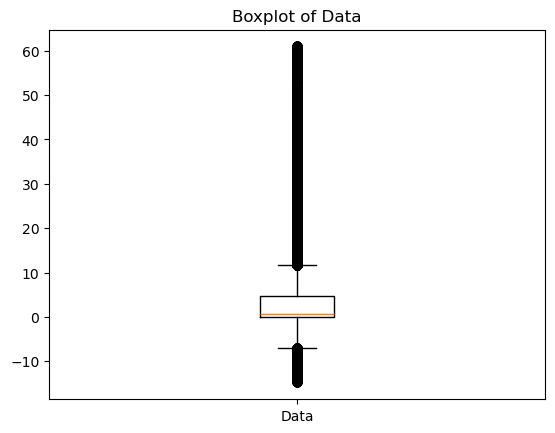

In [35]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(NO_UMRB_12_22_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

### Analysis for normality:

We are able to reject the null hypothesis and conlude our data sets are not normally distributed. Given the normality tests above we can see from the boxplots, histograms and normality test that our datasets are not normally distributed. That being said given the Central Limit Theorem (CLT) I would conclude that our data set is well above the amount needed for CLT to hold ground for these data sets.

## Run F-test and T-test on 12/11/22 assimilation

 - $H_0$: $\mu$<sub>With_UMRB</sub> = $\mu$<sub>NO_UMRB</sub>
 - $H_1$: $\mu$<sub>With_UMRB</sub> != $\mu$<sub>NO_UMRB</sub>

 - alpha = 0.05

In [36]:
# Funcion perfomrs F-test on x and y samples:
def f_test(x, y):
    x = np.array(x)
    y = np.array(y)
    f = np.var(x, ddof=1)/np.var(y, ddof=1) #calculate F test statistic 
    dfn = x.size-1 #define degrees of freedom numerator 
    dfd = y.size-1 #define degrees of freedom denominator 
    p = 2*(1-scipy.stats.f.cdf(f, dfn, dfd)) #find p-value of F test statistic 
    return f, p

In [37]:
F_test_With_Without =  f_test(With_UMRB_12_22_data_final, NO_UMRB_12_22_data_final)
T_test_With_Without = stats.ttest_ind(With_UMRB_12_22_data_final, NO_UMRB_12_22_data_final)

print('With and Witout UMRB Stations \n \t F-statistic: ', F_test_With_Without[0],
      '\n \t associated p-value: ', F_test_With_Without[1],
      '\n \t t-statistic: ', T_test_With_Without[0],
      '\n \t associated p-value: ', T_test_With_Without[1])

With and Witout UMRB Stations 
 	 F-statistic:  0.9978325315052335 
 	 associated p-value:  1.7162056568255057 
 	 t-statistic:  [14.29206439] 
 	 associated p-value:  [2.46557317e-46]


### Anlaysis of T-test:

We can reject the null hypothesis with a p-value of 2.46557317e-46 and an alpha of 0.05. Alough the mean values of both of the data sets were very close to eachother I assume the size of the data set made this difference significantly different. By rejecting the null hypothesis we can infer that the assimilation done on 12/22/22 With UMRB stations is significantly different than the assimilation done Without UMRB stations within the Missouri River Basin region.

# Hypothesis test (T-test) for the 12/28/23 assimilation:

Load netCDF data from with and without UMRB stations and clip to UMRB region (UMRB region shapefile is from USGS watershed boundary set and is the full Missouri Basin extent):

- Load data from assimilation With UMRB stations

In [38]:
## Load data from assmilation with UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated_base\ssm1054_snodas_idw_test_2023122812_central.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray:
With_UMRB_12_28_data = xr.open_dataset(file_path)

With_UMRB_12_28_data = With_UMRB_12_28_data.compute()

With_UMRB_12_28_data


<xarray.Dataset> Size: 39MB
Dimensions:     (lat: 2005, lon: 2413, nv: 2)
Coordinates:
  * lat         (lat) float64 16kB 52.99 52.98 52.97 52.96 ... 36.3 36.3 36.29
  * lon         (lon) float64 19kB -106.2 -106.1 -106.1 ... -86.07 -86.06 -86.05
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 32kB 52.99 52.98 52.98 ... 36.29 36.29 36.28
    lon_bounds  (lon, nv) float64 39kB -106.2 -106.1 -106.1 ... -86.06 -86.05
    Data        (lat, lon) float64 39MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-07-16 22:23:04 UTC created by module: snodas_idw.py
    comment:         2024-07-16 22:23:04 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

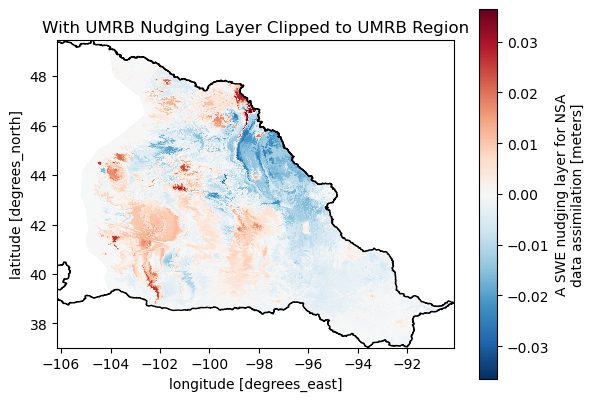

In [39]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
With_UMRB_12_28_data = With_UMRB_12_28_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
With_UMRB_12_28_data = With_UMRB_12_28_data.rio.write_crs('WGS84') #unprojected lon/lat

With_UMRB_12_28_data = With_UMRB_12_28_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
With_UMRB_12_28_data = With_UMRB_12_28_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(With_UMRB_12_28_data.rio.crs)

#clip the model grid to the watershed
With_UMRB_12_28_data_clipped = With_UMRB_12_28_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
With_UMRB_12_28_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('With UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

- Load data from assmilation without UMRB stations

In [40]:
## Load data from assmilation without UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_NO_UMRB_updated\ssm1054_snodas_idw_test_2023122812_central0.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray. The resulting data structure is called a DataFrame
NO_UMRB_12_28_data = xr.open_dataset(file_path)

NO_UMRB_12_28_data = NO_UMRB_12_28_data.compute()

NO_UMRB_12_28_data


<xarray.Dataset> Size: 39MB
Dimensions:     (lat: 2005, lon: 2413, nv: 2)
Coordinates:
  * lat         (lat) float64 16kB 52.99 52.98 52.97 52.96 ... 36.3 36.3 36.29
  * lon         (lon) float64 19kB -106.2 -106.1 -106.1 ... -86.07 -86.06 -86.05
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 32kB 52.99 52.98 52.98 ... 36.29 36.29 36.28
    lon_bounds  (lon, nv) float64 39kB -106.2 -106.1 -106.1 ... -86.06 -86.05
    Data        (lat, lon) float64 39MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-07-16 15:47:45 UTC created by module: snodas_idw.py
    comment:         2024-07-16 15:47:45 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

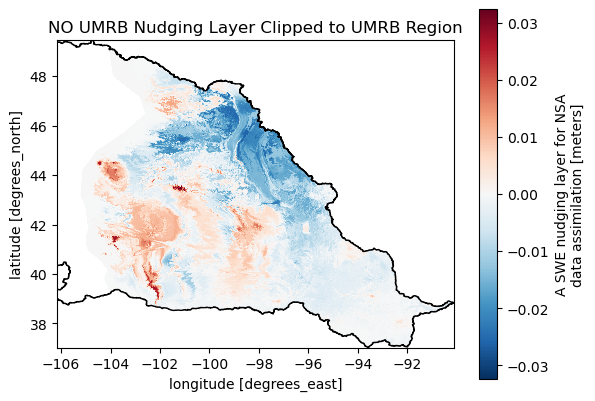

In [41]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
NO_UMRB_12_28_data = NO_UMRB_12_28_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
NO_UMRB_12_28_data = NO_UMRB_12_28_data.rio.write_crs('WGS84') #unprojected lon/lat

NO_UMRB_12_28_data = NO_UMRB_12_28_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
NO_UMRB_12_28_data = NO_UMRB_12_28_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(NO_UMRB_12_28_data.rio.crs)

#clip the model grid to the watershed
NO_UMRB_12_28_data_clipped = NO_UMRB_12_28_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
NO_UMRB_12_28_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('NO UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

### Extract the data from the netCDF files for each assimilation and analyze

With UMRB Stations data anlaysis:

- Extract data from With UMRB run

In [42]:
## Extract data from With UMRB run ##

With_UMRB_12_28_data_final = With_UMRB_12_28_data_clipped['Data']

With_UMRB_12_28_data_final = pd.DataFrame(With_UMRB_12_28_data_clipped['Data'])

# Stack all columns into a single column
With_UMRB_12_28_data_final = With_UMRB_12_28_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
With_UMRB_12_28_data_final = pd.DataFrame(With_UMRB_12_28_data_final, columns=['values'])

# Create array without any zero and -99999 values
#With_UMRB_12_22_data_final = (With_UMRB_12_22_data_final[(With_UMRB_12_22_data_final != 0) & (With_UMRB_12_22_data_final != -99999)])

With_UMRB_12_28_data_final = With_UMRB_12_28_data_final.dropna()

With_UMRB_12_28_data_final = With_UMRB_12_28_data_final * 1000

- Compute basic statistics With UMRB Run

In [43]:
# Compute basic statistics
data_min = np.min(With_UMRB_12_28_data_final)
data_max = np.max(With_UMRB_12_28_data_final)
data_mean = np.mean(With_UMRB_12_28_data_final)
data_std = np.std(With_UMRB_12_28_data_final)

# Compute percentiles
percentiles = np.percentile(With_UMRB_12_28_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -32.83748775720596
Maximum value: 36.41462326049805
Mean value: -1.191883194568309
Standard deviation: values    6.838827
dtype: float64
25th percentile: -3.9759946521371603
Median (50th percentile): -0.6277939246501774
75th percentile: 1.6266256861854345


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in With UMRB run

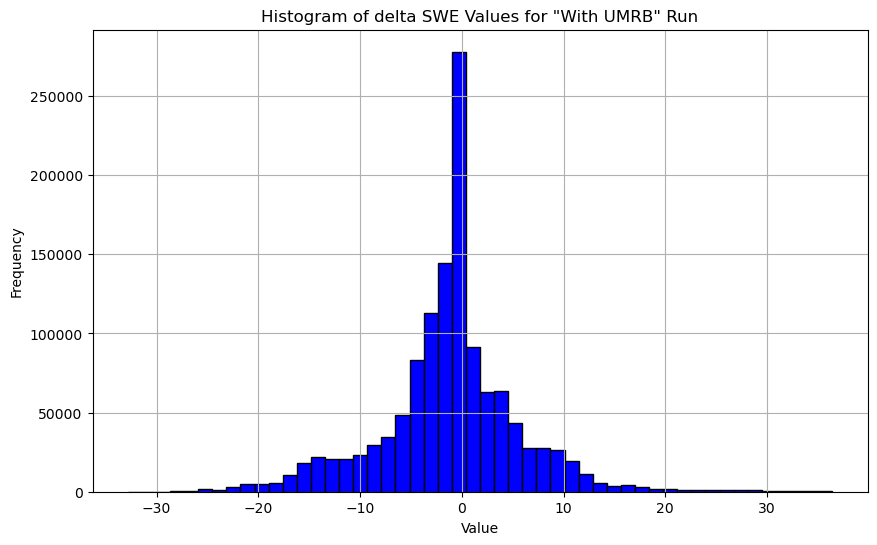

In [44]:
## Create histogram showing the delta SWE in With UMRB run ##

data_flat = With_UMRB_12_28_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "With UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- Extract data from NO UMRB run

In [45]:
## Extract data from NO UMRB run ##

NO_UMRB_12_28_data_final = NO_UMRB_12_28_data_clipped['Data']

NO_UMRB_12_28_data_final = pd.DataFrame(NO_UMRB_12_28_data_clipped['Data'])

# Stack all columns into a single column
NO_UMRB_12_28_data_final = NO_UMRB_12_28_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
NO_UMRB_12_28_data_final = pd.DataFrame(NO_UMRB_12_28_data_final, columns=['values'])

# Create array without any zero and -99999 values
#NO_UMRB_12_22_data_final = (NO_UMRB_12_22_data_final[(NO_UMRB_12_22_data_final != 0) & (NO_UMRB_12_22_data_final != -99999)])

NO_UMRB_12_28_data_final = NO_UMRB_12_28_data_final.dropna()

NO_UMRB_12_28_data_final = NO_UMRB_12_28_data_final * 1000

- Compute basic statistics for NO UMRB Run

In [46]:
# Compute basic statistics
data_min = np.min(NO_UMRB_12_28_data_final)
data_max = np.max(NO_UMRB_12_28_data_final)
data_mean = np.mean(NO_UMRB_12_28_data_final)
data_std = np.std(NO_UMRB_12_28_data_final)

# Compute percentiles
percentiles = np.percentile(NO_UMRB_12_28_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -26.191389188170433
Maximum value: 32.362956553697586
Mean value: -2.349149145163279
Standard deviation: values    7.355363
dtype: float64
25th percentile: -4.942314582876861
Median (50th percentile): -0.9527783549856395
75th percentile: 0.9944692137651145


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in NO UMRB run

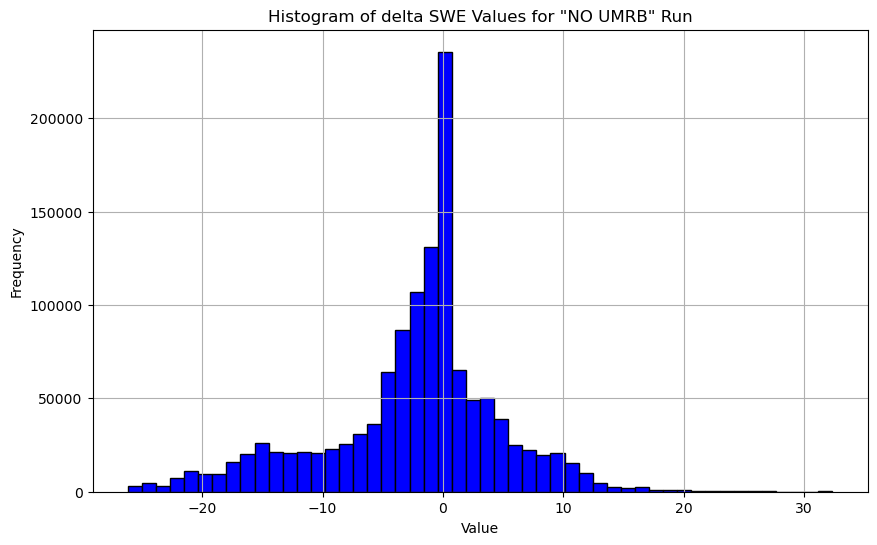

In [47]:
## Create histogram showing the delta SWE in NO UMRB run ##

data_flat_NO = NO_UMRB_12_28_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat_NO, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "NO UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Check for normality of With UMRB dataset (lillietest):

 - $H_0$: The delta SWE distribution of the IDW assimilations are (standard) normal.
 - $H_1$: The delta SWE distribution of the IDW assimilations are not (standard) normal.

In [48]:
# Perform normality test
statistic, p_value = normaltest(With_UMRB_12_28_data_final)

# Print results
p_value

array([0.])

In [49]:
# Perform normality test
statistic, p_value = normaltest(NO_UMRB_12_28_data_final)

# Print results
p_value

array([0.])

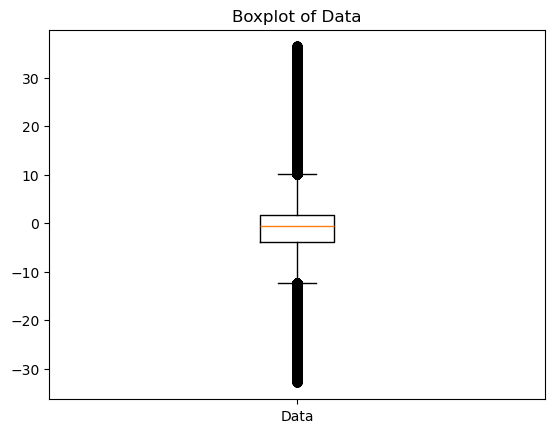

In [50]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(With_UMRB_12_28_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

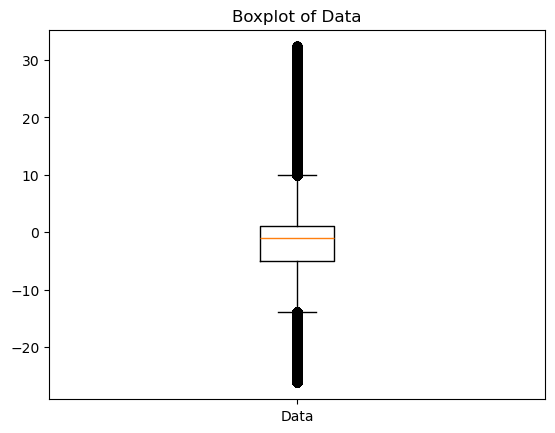

In [51]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(NO_UMRB_12_28_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

### Analysis for normality:

We are able to reject the null hypothesis and conlude our data sets are not normally distributed via lillie test. Although the lillie test conlcuded that our data is not normally distributed, I would argue from the histograms and boxplots that it is farily close. There are obviously some extreme outliers that effect this on both tails but the mean and median are both very close to one another and the box plots highlight this as well. That being said given the Central Limit Theorem (CLT) I would conclude that our data set is well above the amount needed for CLT to hold ground for these data sets.

## Run F-test and T-test on 12/28/23 assimilation

 - $H_0$: $\mu$<sub>With_UMRB</sub> = $\mu$<sub>NO_UMRB</sub>
 - $H_1$: $\mu$<sub>With_UMRB</sub> != $\mu$<sub>NO_UMRB</sub>

 - alpha = 0.05

In [52]:
F_test_With_Without =  f_test(With_UMRB_12_28_data_final, NO_UMRB_12_28_data_final)
T_test_With_Without = stats.ttest_ind(With_UMRB_12_28_data_final, NO_UMRB_12_28_data_final)

print('With and Witout UMRB Stations \n \t F-statistic: ', F_test_With_Without[0],
      '\n \t associated p-value: ', F_test_With_Without[1],
      '\n \t t-statistic: ', T_test_With_Without[0],
      '\n \t associated p-value: ', T_test_With_Without[1])

With and Witout UMRB Stations 
 	 F-statistic:  0.8644800470525413 
 	 associated p-value:  2.0 
 	 t-statistic:  [129.82924452] 
 	 associated p-value:  [0.]


### Anlaysis of T-test:

We can reject the null hypothesis with a p-value that is effectively zero with an alpha of 0.05. Given the amount of data and the difference between the means this is not suprising to see. By rejecting the null hypothesis we can infer that the assimilation done on 12/28/22 With UMRB stations is significantly different than the assimilation done Without UMRB stations, specifically within the Missouri River Basin region.

# Hypothesis test (T-test) for the 01/10/24 Assimilation

Load netCDF data from with and without UMRB stations and clip to UMRB region (UMRB region shapefile is from USGS watershed boundary set and is the full Missouri Basin extent):

- Load data from assimilation With UMRB stations

In [53]:
## Load data from assmilation with UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_2024011012.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray:
With_UMRB_01_10_data = xr.open_dataset(file_path)

With_UMRB_01_10_data = With_UMRB_01_10_data.compute()

With_UMRB_01_10_data


<xarray.Dataset> Size: 85MB
Dimensions:     (lat: 2006, lon: 5257, nv: 2)
Coordinates:
  * lat         (lat) float64 16kB 50.91 50.9 50.9 50.89 ... 34.22 34.21 34.2
  * lon         (lon) float64 42kB -106.1 -106.1 -106.0 ... -62.28 -62.27 -62.26
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 32kB 50.92 50.91 50.91 ... 34.21 34.21 34.2
    lon_bounds  (lon, nv) float64 84kB -106.1 -106.1 -106.1 ... -62.27 -62.26
    Data        (lat, lon) float64 84MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-05-31 14:18:56 UTC created by module: snodas_idw.py
    comment:         2024-05-31 14:18:56 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

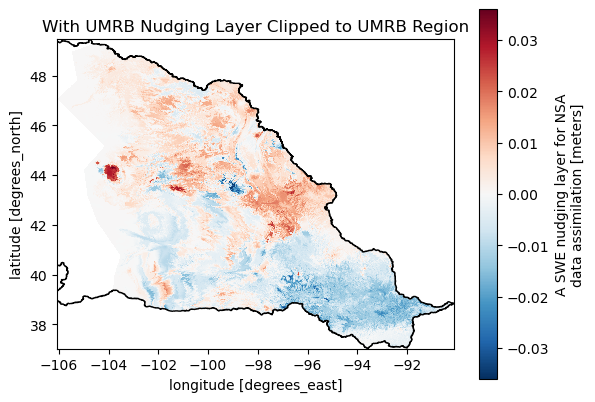

In [54]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
With_UMRB_01_10_data = With_UMRB_01_10_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
With_UMRB_01_10_data = With_UMRB_01_10_data.rio.write_crs('WGS84') #unprojected lon/lat

With_UMRB_01_10_data = With_UMRB_01_10_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
With_UMRB_01_10_data = With_UMRB_01_10_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(With_UMRB_01_10_data.rio.crs)

#clip the model grid to the watershed
With_UMRB_01_10_data_clipped = With_UMRB_01_10_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
With_UMRB_01_10_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('With UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

- Load data from assmilation without UMRB stations

In [55]:
## Load data from assmilation without UMRB stations ##

# Path to your NetCDF file
file_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_2024011012_NO_UMRB\ssm1054_snodas_idw_test_2024011012_central0.nc"

# Path to Missouri Basin Region shapefile
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_and_01_10_Analysis\Data\UMRB_boundary_layer.shp"

# Load shapefile
gdf_missouri_boundary = gpd.read_file(shapefile_path)

#read in the file with xarray. The resulting data structure is called a DataFrame
NO_UMRB_01_10_data = xr.open_dataset(file_path)

NO_UMRB_01_10_data = NO_UMRB_01_10_data.compute()

NO_UMRB_01_10_data


<xarray.Dataset> Size: 85MB
Dimensions:     (lat: 2006, lon: 5257, nv: 2)
Coordinates:
  * lat         (lat) float64 16kB 50.91 50.9 50.9 50.89 ... 34.22 34.21 34.2
  * lon         (lon) float64 42kB -106.1 -106.1 -106.0 ... -62.28 -62.27 -62.26
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 32kB 50.92 50.91 50.91 ... 34.21 34.21 34.2
    lon_bounds  (lon, nv) float64 84kB -106.1 -106.1 -106.1 ... -62.27 -62.26
    Data        (lat, lon) float64 84MB nan nan nan nan nan ... nan nan nan nan
    crs         int32 4B -2147483647
Attributes:
    history:         2024-06-04 18:49:52 UTC created by module: snodas_idw.py
    comment:         2024-06-04 18:49:52 UTC created comment: Data created in...
    format_version:  NOHRSC NetCDF faster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

- Clip data to UMRB region shapefile

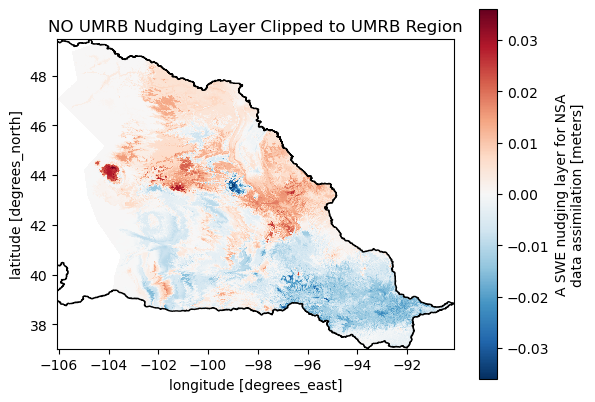

In [56]:
## Clip data to UMRB region shapefile ##

# If dimensions are not 'x' and 'y', set them explicitly
NO_UMRB_01_10_data = NO_UMRB_01_10_data.rio.set_spatial_dims("lon", "lat", inplace=True)

#If the original gridded file was a .asc file, the CRS may already be set (can check by looking at .rio.crs)
NO_UMRB_01_10_data = NO_UMRB_01_10_data.rio.write_crs('WGS84') #unprojected lon/lat

NO_UMRB_01_10_data = NO_UMRB_01_10_data.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
NO_UMRB_01_10_data = NO_UMRB_01_10_data.drop_vars(['lat_bounds', 'lon_bounds'])

#reproject the watershed shapefile to be in the same CRS as the model data
gdf_missouri_boundary = gdf_missouri_boundary.to_crs(NO_UMRB_01_10_data.rio.crs)

#clip the model grid to the watershed
NO_UMRB_01_10_data_clipped = NO_UMRB_01_10_data.rio.clip(gdf_missouri_boundary.geometry)

#plot the first timestep to see clip results
fig, ax = plt.subplots()
NO_UMRB_01_10_data_clipped['Data'].plot(ax = ax)
gdf_missouri_boundary.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('NO UMRB Nudging Layer Clipped to UMRB Region')
ax.set_aspect(1)

### Extract the data from the netCDF files for each assimilation and analyze

With UMRB Stations data anlaysis:

- Extract data from With UMRB run

In [57]:
## Extract data from With UMRB run ##

With_UMRB_01_10_data_final = With_UMRB_01_10_data_clipped['Data']

With_UMRB_01_10_data_final = pd.DataFrame(With_UMRB_01_10_data_clipped['Data'])

# Stack all columns into a single column
With_UMRB_01_10_data_final = With_UMRB_01_10_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
With_UMRB_01_10_data_final = pd.DataFrame(With_UMRB_01_10_data_final, columns=['values'])

# Create array without any zero and -99999 values
#With_UMRB_12_22_data_final = (With_UMRB_12_22_data_final[(With_UMRB_12_22_data_final != 0) & (With_UMRB_12_22_data_final != -99999)])

With_UMRB_01_10_data_final = With_UMRB_01_10_data_final.dropna()

With_UMRB_01_10_data_final = With_UMRB_01_10_data_final * 1000

- Compute basic statistics With UMRB Run

In [58]:
# Compute basic statistics
data_min = np.min(With_UMRB_01_10_data_final)
data_max = np.max(With_UMRB_01_10_data_final)
data_mean = np.mean(With_UMRB_01_10_data_final)
data_std = np.std(With_UMRB_01_10_data_final)

# Compute percentiles
percentiles = np.percentile(With_UMRB_01_10_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -34.68750789761543
Maximum value: 35.98286956548691
Mean value: -0.04095067488586456
Standard deviation: values    7.272332
dtype: float64
25th percentile: -4.04905725736171
Median (50th percentile): 0.019721204807865433
75th percentile: 3.9006166625767946


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in With UMRB run

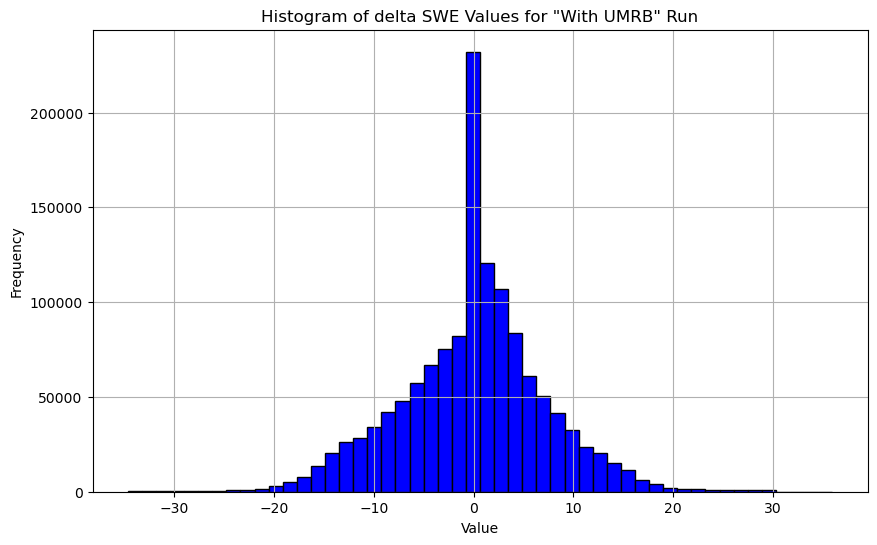

In [59]:
## Create histogram showing the delta SWE in With UMRB run ##

data_flat = With_UMRB_01_10_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "With UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- Extract data from NO UMRB run

In [60]:
## Extract data from NO UMRB run ##

NO_UMRB_01_10_data_final = NO_UMRB_01_10_data_clipped['Data']

NO_UMRB_01_10_data_final = pd.DataFrame(NO_UMRB_01_10_data_clipped['Data'])

# Stack all columns into a single column
NO_UMRB_01_10_data_final = NO_UMRB_01_10_data_final.stack().reset_index(drop=True)

# Optionally, you can give a name to the single column
NO_UMRB_01_10_data_final = pd.DataFrame(NO_UMRB_01_10_data_final, columns=['values'])

# Create array without any zero and -99999 values
#NO_UMRB_12_22_data_final = (NO_UMRB_12_22_data_final[(NO_UMRB_12_22_data_final != 0) & (NO_UMRB_12_22_data_final != -99999)])

NO_UMRB_01_10_data_final = NO_UMRB_01_10_data_final.dropna()

NO_UMRB_01_10_data_final = NO_UMRB_01_10_data_final * 1000

- Compute basic statistics for NO UMRB Run

In [61]:
# Compute basic statistics
data_min = np.min(NO_UMRB_01_10_data_final)
data_max = np.max(NO_UMRB_01_10_data_final)
data_mean = np.mean(NO_UMRB_01_10_data_final)
data_std = np.std(NO_UMRB_01_10_data_final)

# Compute percentiles
percentiles = np.percentile(NO_UMRB_01_10_data_final, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])

Minimum value: -34.68750789761543
Maximum value: 35.98286956548691
Mean value: 0.2660775466695712
Standard deviation: values    7.447512
dtype: float64
25th percentile: -3.7682477850466967
Median (50th percentile): 0.026244430046062917
75th percentile: 4.667534492909908


c:\Users\clemasters\AppData\Local\miniconda3\envs\umrb-snodas\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


- Create histogram showing the delta SWE in NO UMRB run

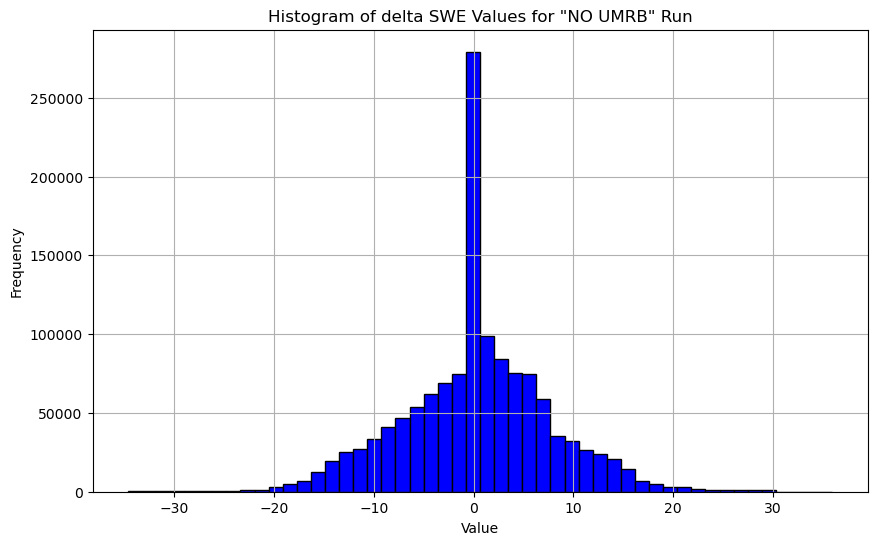

In [62]:
## Create histogram showing the delta SWE in NO UMRB run ##

data_flat_NO = NO_UMRB_01_10_data_final.values.flatten()

plt.figure(figsize=(10, 6))
plt.hist(data_flat_NO, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of delta SWE Values for "NO UMRB" Run')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Check for normality of With UMRB dataset (lillietest):

 - $H_0$: The delta SWE distribution of the IDW assimilations are (standard) normal.
 - $H_1$: The delta SWE distribution of the IDW assimilations are not (standard) normal.

In [63]:
# Perform normality test
statistic, p_value = normaltest(With_UMRB_01_10_data_final)

# Print results
p_value

array([0.])

In [64]:
# Perform normality test
statistic, p_value = normaltest(NO_UMRB_01_10_data_final)

# Print results
p_value

array([0.])

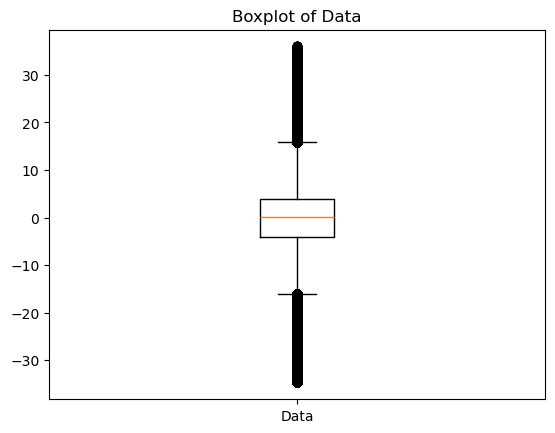

In [65]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(With_UMRB_01_10_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

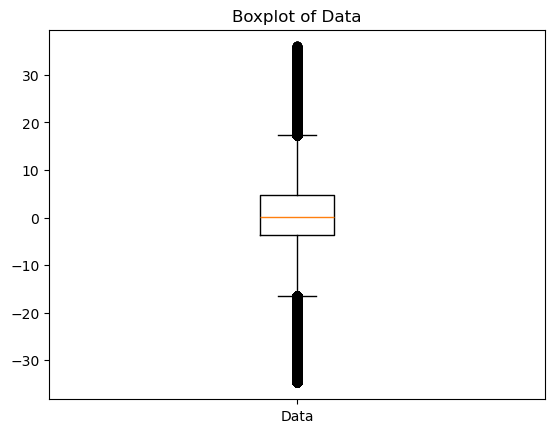

In [66]:
# Create a figure and axis
fig, ax = plt.subplots()

# Create a boxplot
ax.boxplot(NO_UMRB_01_10_data_final)

# Customize labels and title
ax.set_xticklabels(['Data'])
ax.set_title('Boxplot of Data')

# Show plot
plt.show()

### Analysis for normality:

We are able to reject the null hypothesis and conlude our data sets are not normally distributed. The lillie test conlcuded that our data is not normally distributed but would argue from the histograms and boxplots that they are indeed normally distributed with just a lot of extreme outliers on both ends. The mean and median are both very close to one another and the plots highlight this as well. That being said given the Central Limit Theorem (CLT) I would conclude that our data set is well above the amount needed for CLT to hold ground for these data sets.

## Run F-test and T-test on 01/10/24 assimilation

 - $H_0$: $\mu$<sub>With_UMRB</sub> = $\mu$<sub>NO_UMRB</sub>
 - $H_1$: $\mu$<sub>With_UMRB</sub> != $\mu$<sub>NO_UMRB</sub>

 - alpha = 0.05

In [67]:
F_test_With_Without =  f_test(With_UMRB_01_10_data_final, NO_UMRB_01_10_data_final)
T_test_With_Without = stats.ttest_ind(With_UMRB_01_10_data_final, NO_UMRB_01_10_data_final)

print('With and Witout UMRB Stations \n \t F-statistic: ', F_test_With_Without[0],
      '\n \t associated p-value: ', F_test_With_Without[1],
      '\n \t t-statistic: ', T_test_With_Without[0],
      '\n \t associated p-value: ', T_test_With_Without[1])

With and Witout UMRB Stations 
 	 F-statistic:  0.953509430867517 
 	 associated p-value:  2.0 
 	 t-statistic:  [-34.07292105] 
 	 associated p-value:  [2.10838178e-254]


### Anlaysis of T-test:

We can reject the null hypothesis with a p-value of 2.10838178e-254 and an alpha of 0.05. Given the amount of data and the difference between the means this is not suprising to see. By rejecting the null hypothesis we can infer that the assimilation done on 01/10/24 With UMRB stations is significantly different than the assimilation done Without UMRB stations, specifically within the Missouri River Basin region.

# Final Analysis

After running hypothesis tests on each assimilation date we can see that the runs with UMRB stations are significantly different from the runs without UMRB stations. The p-values were extremely small, ranging from 0 to 2.46*10^-46. We can also further examine the descriptive statistics from the assimilations within the UMRB region. We can see in the assimilations on 12/28/23 and 12/11/22 that the assimilations without UMRB stations showed lower overall SWE within the assimilated region. The 12/28/23 assimilation without UMRB stations showed a mean delta SWE of -2.349 mm, while the assimilation with UMRB stations showed a delta SWE of -1.192 mm. This was on overall increase in the average delta SWE of 1.157 mm within the assimulated region. The 12/11/22 assimilation without UMRB stations had a mean delta SWE of 2.864 mm, while the assimilation with UMRB stations had a delta SWE of 2.967 mm. This was an overall increase of 0.103 mm within the assimulated region. The assimilation on 01/10/24 showed an overall decrease in SWE throughout the assimilated region with a mean delta SWE of 0.266 mm for the assimilation without UMRB stations and a mean delta SWE of -0.041 mm when the stations were included. 